# Stock Price Analysis, Forecasting & Prediction — AAPL (10-Year Data)



## Setup — install & import libraries

In [ ]:
!pip install -q yfinance pmdarima prophet plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from prophet import Prophet

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from joblib import dump
import json as json_lib

np.random.seed(42)

## Download data
10 years of daily data for AAPL, ending on 2026-08-02 (today's date)
`auto_adjust=True` gives split/dividend-adjusted prices, which is standard for price forecasting.

In [ ]:
TICKER = "AAPL"
END_DATE = "2026-08-02"
START_DATE = "2016-08-02"   # exactly 10 years back

raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

# Flatten yfinance's MultiIndex columns (Price, Ticker) -> just Price
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

raw = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
raw.index.name = "Date"

print(raw.shape)
raw.head()


[*********************100%***********************]  1 of 1 completed

(2513, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2016-08-02,24.142246,24.146798,23.675563,23.784836,135266400
2016-08-03,23.859960,24.094439,23.850854,24.083057,120810400
2016-08-04,24.165456,24.261587,24.096791,24.231833,109634800
2016-08-05,24.323381,24.639240,24.302782,24.600330,162213600
2016-08-08,24.609481,24.804033,24.527085,24.804033,112148800


In [ ]:
raw.tail()


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-07-27,334.540009,339.570007,334.019989,336.910004,49604300
2026-07-28,340.029999,342.890015,335.600006,340.079987,51859000
2026-07-29,339.730011,344.570007,337.350006,338.190002,56090800
2026-07-30,333.100006,334.750000,329.589996,333.429993,74817800
2026-07-31,304.809998,310.690002,300.000000,308.910004,132275300


In [ ]:
# Basic sanity checks
print("Missing values per column:")
print(raw.isnull().sum())
print("\nDate range:", raw.index.min(), "to", raw.index.max())
print("Any duplicate dates:", raw.index.duplicated().sum())


Missing values per column:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Date range: 2016-08-02 00:00:00 to 2026-07-31 00:00:00
Any duplicate dates: 0


## Exploratory Data Analysis (EDA)

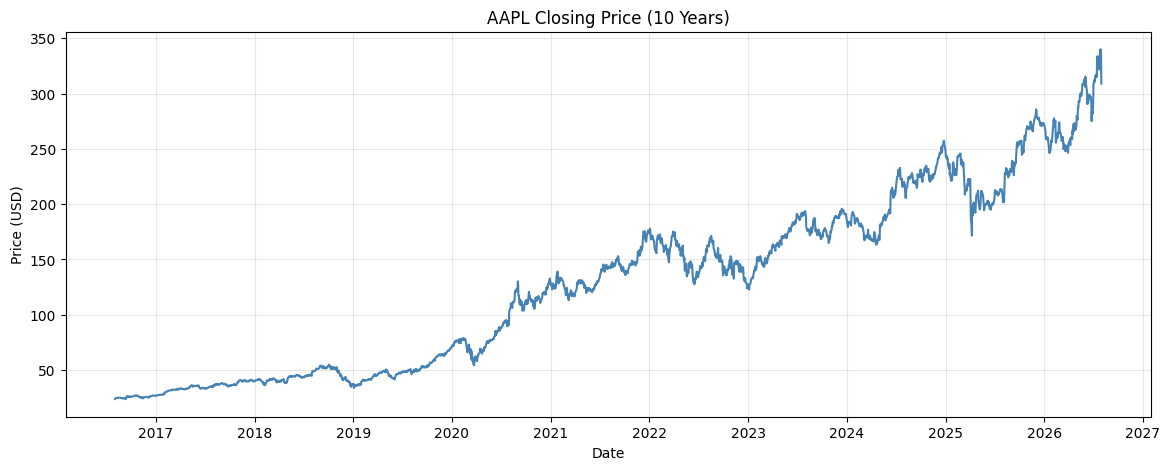

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(raw.index, raw["Close"], color="steelblue")
plt.title(f"{TICKER} Closing Price (10 Years)")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
fig = go.Figure(data=[go.Candlestick(
    x=raw.index, open=raw["Open"], high=raw["High"], low=raw["Low"], close=raw["Close"]
)])
fig.update_layout(title=f"{TICKER} Candlestick Chart", xaxis_title="Date", yaxis_title="Price (USD)",
                   xaxis_rangeslider_visible=False, template="plotly_dark")
fig.show()

In [ ]:
# Moving averages
raw["MA_20"] = raw["Close"].rolling(20).mean()
raw["MA_50"] = raw["Close"].rolling(50).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=raw.index, y=raw["Close"], name="Close", line=dict(color="blue", width=1)))
fig.add_trace(go.Scatter(x=raw.index, y=raw["MA_20"], name="20-Day MA", line=dict(color="orange", width=1)))
fig.add_trace(go.Scatter(x=raw.index, y=raw["MA_50"], name="50-Day MA", line=dict(color="red", width=1)))
fig.update_layout(title=f"{TICKER} Price with Moving Averages", xaxis_title="Date", yaxis_title="Price (USD)",
                   template="plotly_dark")
fig.show()

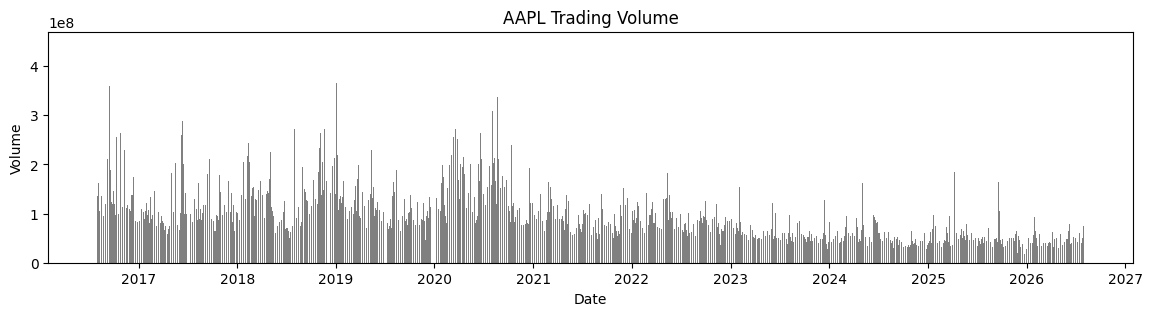

In [ ]:
plt.figure(figsize=(14, 3))
plt.bar(raw.index, raw["Volume"], color="grey", width=1)
plt.title(f"{TICKER} Trading Volume")
plt.xlabel("Date"); plt.ylabel("Volume")
plt.show()

##  Stationarity checks & decomposition
Stock prices are almost always non-stationary (they trend). We confirm this with the Augmented Dickey-Fuller
test.

In [ ]:
def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    for key, value in result[4].items():
        print(f"  Critical Value ({key}): {value:.3f}")
    verdict = "STATIONARY" if result[1] <= 0.05 else "NOT stationary"
    print(f"Verdict: {verdict}\n")
    return result[1] <= 0.05

adf_test(raw["Close"], "Raw Close Price")

log_returns = np.log(raw["Close"]).diff().dropna()
adf_test(log_returns, "Log Returns (differenced)")

--- ADF Test: Raw Close Price ---
ADF Statistic: 0.3432
p-value: 0.979243
  Critical Value (1%): -3.433
  Critical Value (5%): -2.863
  Critical Value (10%): -2.567
Verdict: NOT stationary

--- ADF Test: Log Returns (differenced) ---
ADF Statistic: -16.4255
p-value: 0.000000
  Critical Value (1%): -3.433
  Critical Value (5%): -2.863
  Critical Value (10%): -2.567
Verdict: STATIONARY



np.True_

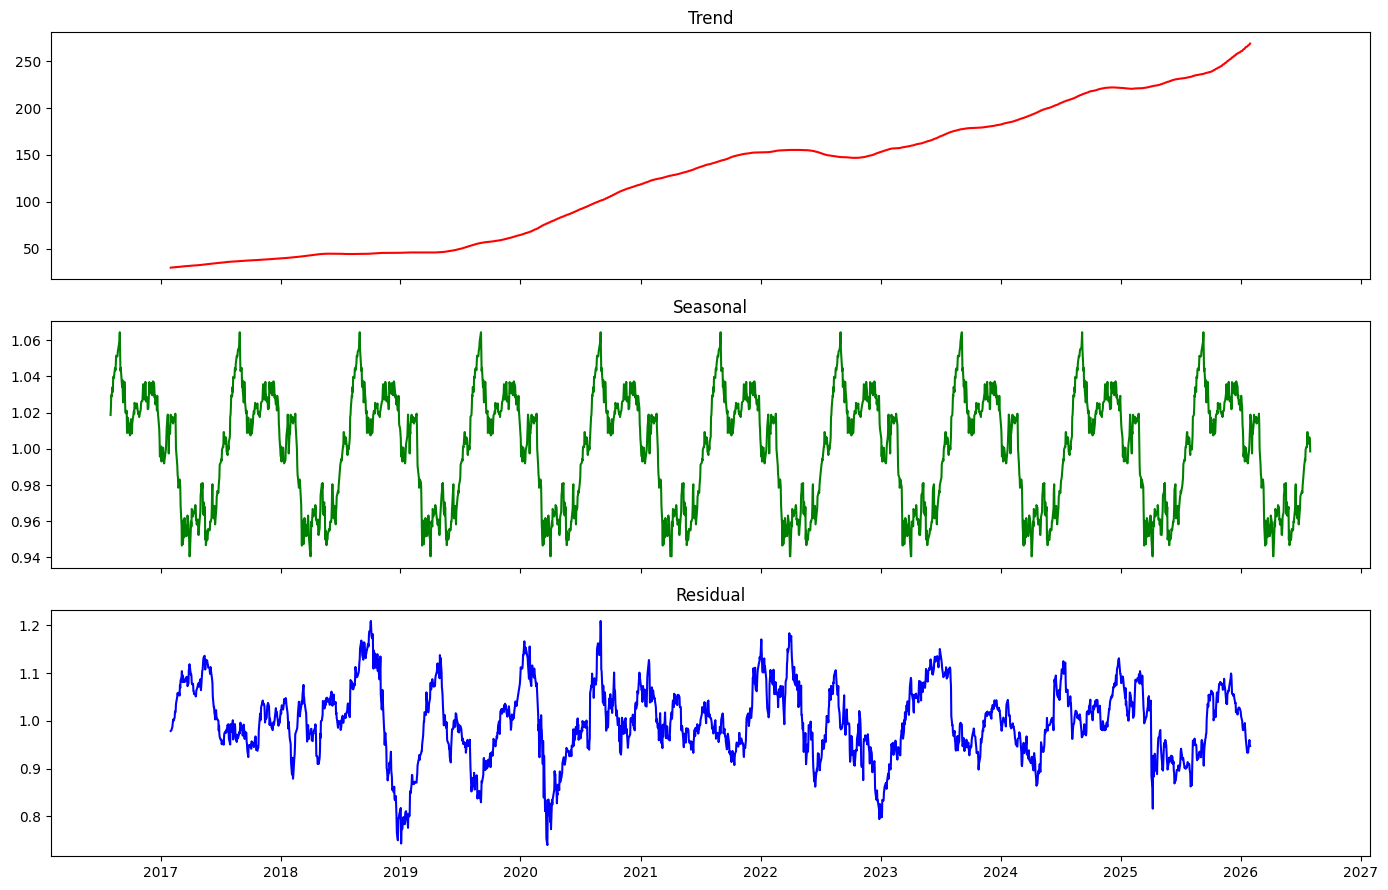

In [ ]:
decomp = seasonal_decompose(raw["Close"], model="multiplicative", period=252) #from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(decomp.trend, color="red"); axes[0].set_title("Trend")
axes[1].plot(decomp.seasonal, color="green"); axes[1].set_title("Seasonal")
axes[2].plot(decomp.resid, color="blue"); axes[2].set_title("Residual")
plt.tight_layout()
plt.show()


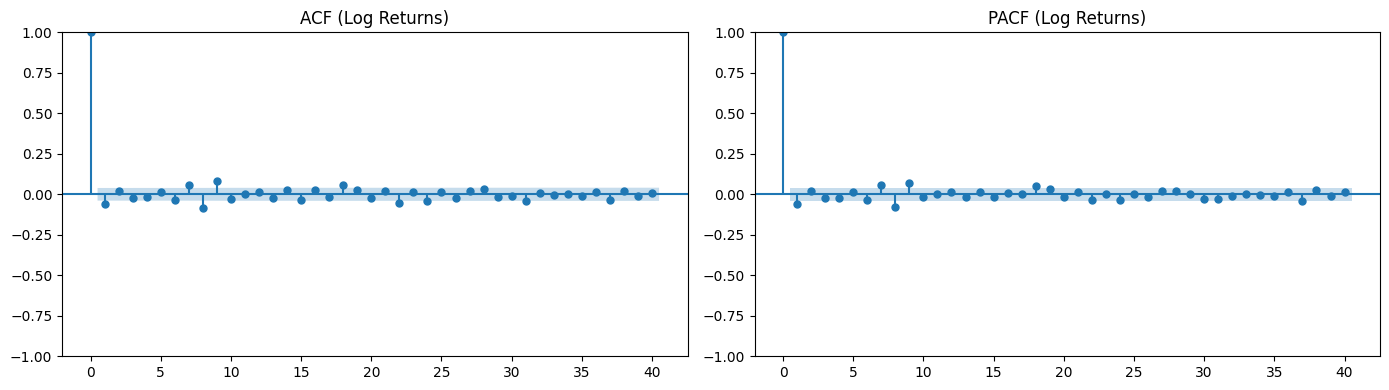

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(log_returns, ax=axes[0], lags=40); axes[0].set_title("ACF (Log Returns)")
plot_pacf(log_returns, ax=axes[1], lags=40); axes[1].set_title("PACF (Log Returns)")
plt.tight_layout()
plt.show()

##Train/Test split — used identically by every model


In [ ]:
SPLIT_RATIO = 0.8
split_idx = int(len(raw) * SPLIT_RATIO)

train_df = raw.iloc[:split_idx].copy()
test_df  = raw.iloc[split_idx:].copy()

print(f"Train: {train_df.index.min().date()} to {train_df.index.max().date()}  ({len(train_df)} rows)")
print(f"Test:  {test_df.index.min().date()} to {test_df.index.max().date()}  ({len(test_df)} rows)")

Train: 2016-08-02 to 2024-07-29  (2010 rows)
Test:  2024-07-30 to 2026-07-31  (503 rows)


train_test_split(),
By default, it shuffles the data. For time series,
that is not appropriate because it mixes past and future observations.

In [ ]:
# Shared evaluation helper -> every model logs into this same dict, in the same $ scale
results = {}

def evaluate_forecast(actual, predicted, model_name):
    actual = np.asarray(actual).flatten()
    predicted = np.asarray(predicted).flatten()
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    results[model_name] = {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape}
    print(f"{model_name:20s} | MAE: {mae:8.3f}  RMSE: {rmse:8.3f}  MAPE: {mape:6.3f}%")
    return mae, rmse, mape

## Naive baseline (persistence model)
The single most important sanity check in stock forecasting: "tomorrow's price = today's price".


In [ ]:
naive_preds = np.concatenate([[train_df["Close"].iloc[-1]], test_df["Close"].values[:-1]])
evaluate_forecast(test_df["Close"].values, naive_preds, "Naive Baseline")


Naive Baseline       | MAE:    2.909  RMSE:    4.295  MAPE:  1.204%


(2.9092057760856735,
 np.float64(4.294660154806288),
 np.float64(1.2038676864003763))

## ARIMA (non-seasonal) — fit on TRAIN only


In [ ]:
arima_model = auto_arima(train_df["Close"], seasonal=False, trace=True,
                          error_action="ignore", suppress_warnings=True)
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8559.361, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8560.576, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8560.538, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8561.816, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8562.884, Time=0.37 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 2.788 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2010
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4277.681
Date:                Sun, 02 Aug 2026   AIC                           8559.361
Time:                        16:13:23   BIC                           8570.572
Sample:                             0   HQIC                          8563.477
               

ARIMA                | MAE:   19.042  RMSE:   24.615  MAPE:  7.735%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



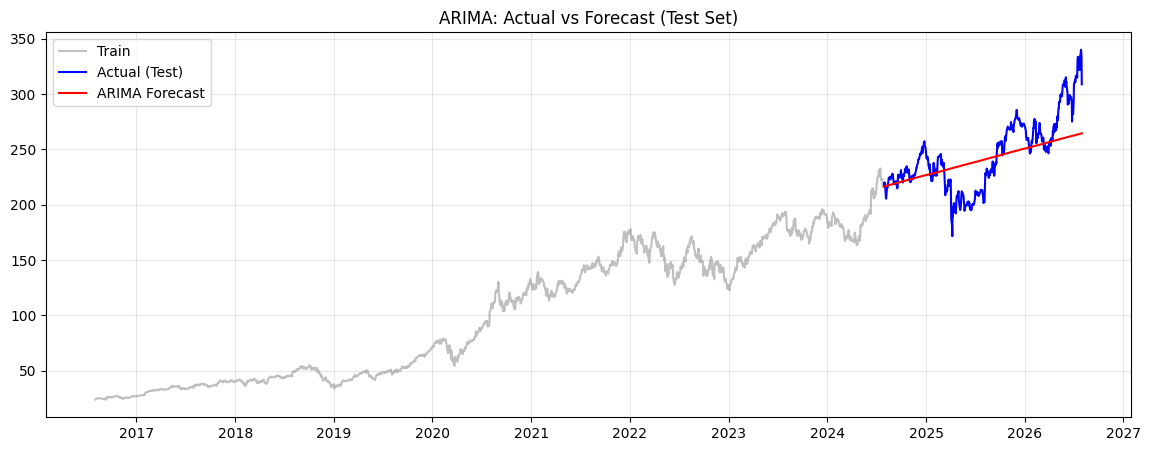

In [ ]:
arima_forecast = arima_model.predict(n_periods=len(test_df))
evaluate_forecast(test_df["Close"].values, arima_forecast, "ARIMA")

plt.figure(figsize=(14, 5))
plt.plot(train_df.index, train_df["Close"], label="Train", color="grey", alpha=0.5)
plt.plot(test_df.index, test_df["Close"], label="Actual (Test)", color="blue")
plt.plot(test_df.index, arima_forecast, label="ARIMA Forecast", color="red")
plt.title("ARIMA: Actual vs Forecast (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## SARIMAX — seasonal order selected via auto_arima on TRAIN

In [ ]:
sarimax_auto = auto_arima(train_df["Close"], seasonal=True, m=5, trace=True,
                           error_action="ignore", suppress_warnings=True,
                           stepwise=True, max_order=None)
print(sarimax_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=8566.182, Time=3.96 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=8559.361, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=8561.537, Time=0.25 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=8561.451, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=8561.816, Time=0.04 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=8560.311, Time=0.18 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=8560.259, Time=0.19 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=8560.225, Time=0.67 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=8560.576, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=8560.538, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=8562.884, Time=0.37 sec

Best model:  ARIMA(0,1,0)(0,0,0)[5] intercept
Total fit time: 6.344 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2

SARIMAX              | MAE:   19.042  RMSE:   24.615  MAPE:  7.735%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



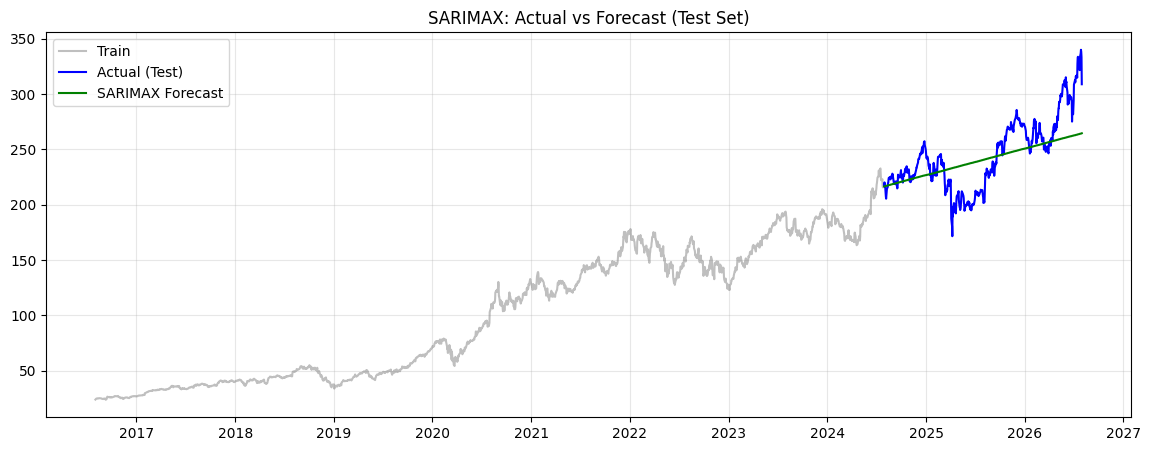

In [ ]:
sarimax_forecast = sarimax_auto.predict(n_periods=len(test_df))
evaluate_forecast(test_df["Close"].values, sarimax_forecast, "SARIMAX")

plt.figure(figsize=(14, 5))
plt.plot(train_df.index, train_df["Close"], label="Train", color="grey", alpha=0.5)
plt.plot(test_df.index, test_df["Close"], label="Actual (Test)", color="blue")
plt.plot(test_df.index, sarimax_forecast, label="SARIMAX Forecast", color="green")
plt.title("SARIMAX: Actual vs Forecast (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Residual diagnostics on the SARIMAX model (Ljung-Box: p > 0.05 means residuals look like white noise)
residuals = pd.Series(sarimax_auto.resid())
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_box)


      lb_stat  lb_pvalue
10  16.786663    0.07922


In [ ]:
N_STEPS = 100  # how many past days the model looks at to predict the next day

train_close = train_df[["Close"]].values
test_close  = test_df[["Close"]].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_close)              # fit on TRAIN ONLY

train_scaled = scaler.transform(train_close)
test_scaled  = scaler.transform(test_close)

def create_sequences(scaled_series, n_steps):
    X, y = [], []
    for i in range(n_steps, len(scaled_series)):
        X.append(scaled_series[i - n_steps:i, 0])
        y.append(scaled_series[i, 0])
    return np.array(X), np.array(y)

X_train_full, y_train_full = create_sequences(train_scaled, N_STEPS)

# To generate test-set predictions we need the N_STEPS days *before* each test day.
# Prepending the tail of TRAIN is standard practice and introduces no leakage: every
# prediction for a test day only uses information strictly before that day.
combined_scaled = np.concatenate([train_scaled[-N_STEPS:], test_scaled], axis=0)
X_test, y_test = create_sequences(combined_scaled, N_STEPS)

# Carve a validation set out of TRAIN only (last 10%), chronologically -- never use test here
val_cut = int(len(X_train_full) * 0.9)
X_tr, X_val = X_train_full[:val_cut], X_train_full[val_cut:]
y_tr, y_val = y_train_full[:val_cut], y_train_full[val_cut:]

X_tr  = X_tr.reshape((X_tr.shape[0], X_tr.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train shape:", X_tr.shape, " Val shape:", X_val.shape, " Test shape:", X_test.shape)


Train shape: (1719, 100, 1)  Val shape: (191, 100, 1)  Test shape: (503, 100, 1)


In [ ]:
def build_lstm(n_steps):
    model = Sequential([
        Input(shape=(n_steps, 1)),
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        LSTM(32, return_sequences=False, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(16, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error")
    return model

lstm_model = build_lstm(N_STEPS)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),   # validation from TRAIN tail, not from test
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.1055 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0565 - val_loss: 0.0424 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0374 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0273 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0212 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0172 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0141 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0120 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0102 - val_loss: 0.0120 - learning_rate: 0.0010
Epoch 10/1

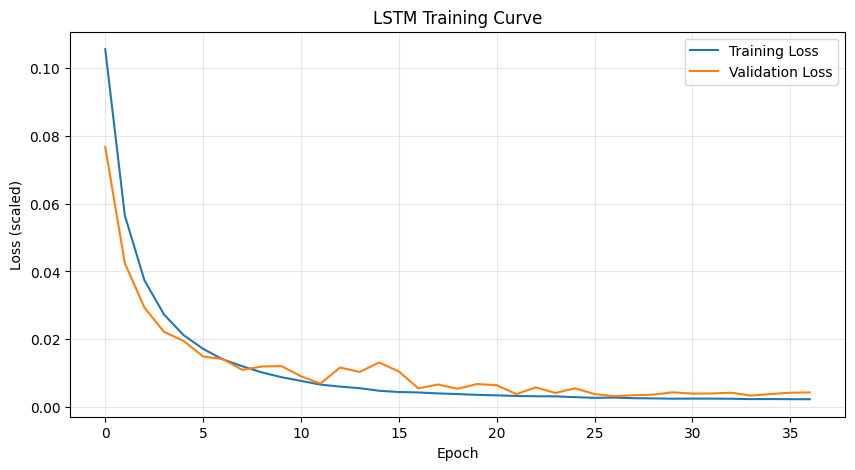

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Curve"); plt.xlabel("Epoch"); plt.ylabel("Loss (scaled)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

LSTM                 | MAE:   15.705  RMSE:   19.652  MAPE:  6.068%


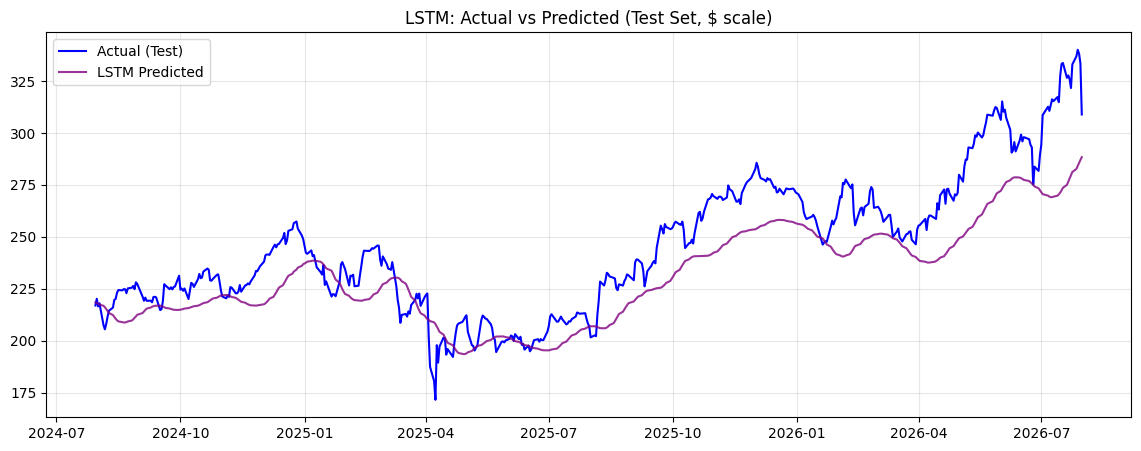

In [ ]:
# Predict on test set, then inverse-transform back to dollars before scoring
test_preds_scaled = lstm_model.predict(X_test, verbose=0)
test_preds_dollars = scaler.inverse_transform(test_preds_scaled).flatten()
test_actual_dollars = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

evaluate_forecast(test_actual_dollars, test_preds_dollars, "LSTM")

plt.figure(figsize=(14, 5))
plt.plot(test_df.index[-len(test_actual_dollars):], test_actual_dollars, label="Actual (Test)", color="blue")
plt.plot(test_df.index[-len(test_preds_dollars):], test_preds_dollars, label="LSTM Predicted", color="purple", alpha=0.8)
plt.title("LSTM: Actual vs Predicted (Test Set, $ scale)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Facebook Prophet Model


In [ ]:
prophet_train = train_df.reset_index()[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})
prophet_test  = test_df.reset_index()[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})

prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(prophet_train)


Prophet              | MAE:   18.979  RMSE:   22.727  MAPE:  7.779%


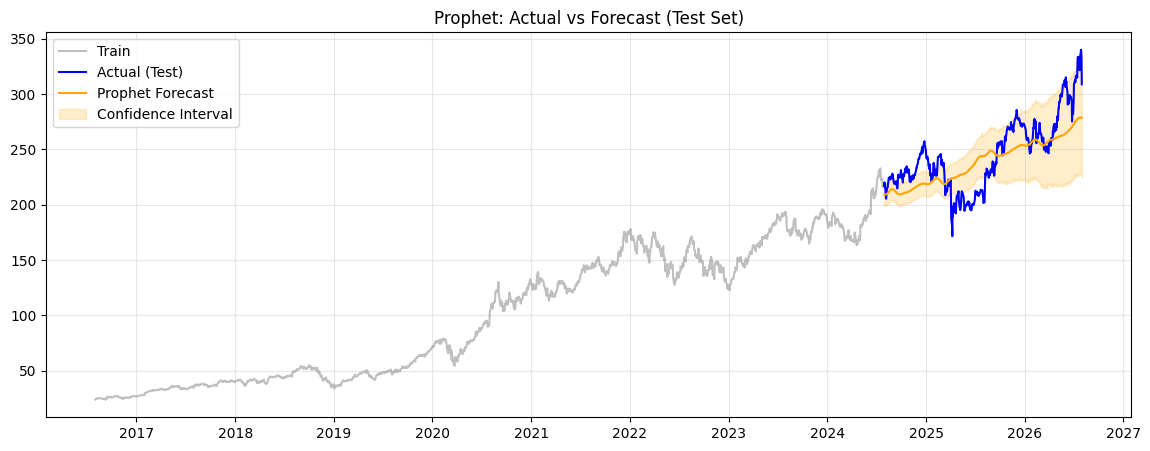

In [ ]:
prophet_forecast = prophet_model.predict(prophet_test[["ds"]])
evaluate_forecast(prophet_test["y"].values, prophet_forecast["yhat"].values, "Prophet")

plt.figure(figsize=(14, 5))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train", color="grey", alpha=0.5)
plt.plot(prophet_test["ds"], prophet_test["y"], label="Actual (Test)", color="blue")
plt.plot(prophet_test["ds"], prophet_forecast["yhat"], label="Prophet Forecast", color="orange")
plt.fill_between(prophet_test["ds"], prophet_forecast["yhat_lower"], prophet_forecast["yhat_upper"],
                  color="orange", alpha=0.2, label="Confidence Interval")
plt.title("Prophet: Actual vs Forecast (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Model comparison — same test set, same scale, all models included

In [ ]:
comparison_df = pd.DataFrame(results).T.sort_values("RMSE")
comparison_df

,MAE,RMSE,MAPE (%)
Naive Baseline,2.909206,4.294660,1.203868
LSTM,15.704900,19.651744,6.067787
Prophet,18.978932,22.727353,7.778896
ARIMA,19.041915,24.614507,7.735174
SARIMAX,19.041915,24.614507,7.735174


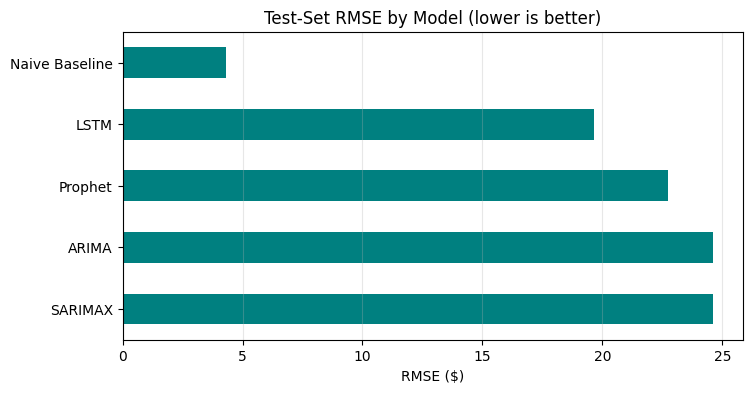

In [ ]:
comparison_df["RMSE"].plot(kind="barh", figsize=(8, 4), color="teal")
plt.title("Test-Set RMSE by Model (lower is better)")
plt.xlabel("RMSE ($)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis="x")
plt.show()

## Models retrain on full data for deployment
 We refit **LSTM** and **Prophet** on the **entire dataset** (train+test combined) so the
deployed models use every available day of real data and can genuinely forecast beyond 2026-08-02.


In [ ]:
full_close = raw[["Close"]].values

# Full-data scaler -- this is the one that ships with the deployed LSTM
scaler_full = MinMaxScaler(feature_range=(0, 1))
full_scaled = scaler_full.fit_transform(full_close)

X_full, y_full = create_sequences(full_scaled, N_STEPS)

val_cut_full = int(len(X_full) * 0.9)
X_full_tr, X_full_val = X_full[:val_cut_full], X_full[val_cut_full:]
y_full_tr, y_full_val = y_full[:val_cut_full], y_full[val_cut_full:]

X_full_tr  = X_full_tr.reshape((X_full_tr.shape[0], X_full_tr.shape[1], 1))
X_full_val = X_full_val.reshape((X_full_val.shape[0], X_full_val.shape[1], 1))

lstm_production = build_lstm(N_STEPS)
history_full = lstm_production.fit(
    X_full_tr, y_full_tr,
    validation_data=(X_full_val, y_full_val),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
               ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)],
    verbose=1
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.0965 - val_loss: 0.0623 - learning_rate: 0.0010
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0445 - val_loss: 0.0383 - learning_rate: 0.0010
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0273 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0185 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0140 - val_loss: 0.0148 - learning_rate: 0.0010
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0107 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0085 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0070 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 9/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0058 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 10/1

In [ ]:
# Refit Prophet on the FULL dataset
prophet_full_df = raw.reset_index()[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})
prophet_production = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
prophet_production.fit(prophet_full_df)

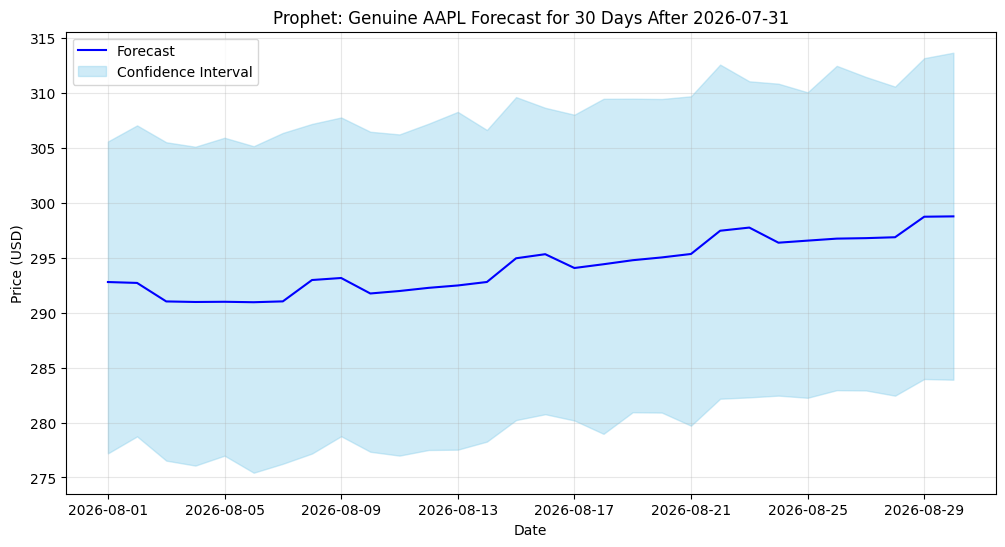

,ds,yhat,yhat_lower,yhat_upper
0,2026-08-01,292.799834,277.194531,305.599100
1,2026-08-02,292.718217,278.740973,307.065013
2,2026-08-03,291.033284,276.534077,305.528834
3,2026-08-04,290.983228,276.081948,305.120006
4,2026-08-05,291.001668,276.985835,305.940296
5,2026-08-06,290.960848,275.431973,305.169651
6,2026-08-07,291.038372,276.245473,306.378385
7,2026-08-08,292.982603,277.179617,307.198031
8,2026-08-09,293.167470,278.756525,307.786316
9,2026-08-10,291.756847,277.340697,306.487433


In [ ]:
# Genuine future forecast: next 30 days AFTER the end of the dataset (2026-08-02)
future = prophet_production.make_future_dataframe(periods=30, freq="D", include_history=False)
future_forecast = prophet_production.predict(future)

plt.figure(figsize=(12, 6))
plt.plot(future_forecast["ds"], future_forecast["yhat"], label="Forecast", color="blue")
plt.fill_between(future_forecast["ds"], future_forecast["yhat_lower"], future_forecast["yhat_upper"],
                  color="skyblue", alpha=0.4, label="Confidence Interval")
plt.title(f"Prophet: Genuine {TICKER} Forecast for 30 Days After {raw.index.max().date()}")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)


In [ ]:
# Genuine recursive multi-day LSTM forecast for the same 30 days beyond the dataset
# (Recursive = each predicted day is fed back in as input for the next day; error compounds
#  with horizon, which is normal and expected -- shown here for the demo, not for scoring.)
n_future_days = 30
last_sequence = full_scaled[-N_STEPS:].copy()
future_preds_scaled = []

for _ in range(n_future_days):
    inp = last_sequence.reshape(1, N_STEPS, 1)
    next_pred = lstm_production.predict(inp, verbose=0)
    future_preds_scaled.append(next_pred[0, 0])
    last_sequence = np.append(last_sequence[1:], next_pred, axis=0)

future_preds_dollars = scaler_full.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()
future_dates = pd.date_range(raw.index.max(), periods=n_future_days + 1, freq="B")[1:]

plt.figure(figsize=(12, 6))
plt.plot(raw.index[-120:], raw["Close"].iloc[-120:], label="Recent Actual", color="blue")
plt.plot(future_dates, future_preds_dollars, label="LSTM Recursive Forecast", color="darkorange")
plt.title(f"LSTM: Recursive {n_future_days}-Day Forecast Beyond {raw.index.max().date()}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## Save production artifacts for deployment


In [ ]:
dump(scaler_full, "scaler.joblib")
lstm_production.save("lstm_model.keras")
dump(prophet_production, "fb_prophet_model.joblib")

metadata = {
    "ticker": TICKER,
    "n_steps": N_STEPS,
    "trained_through": str(raw.index.max().date()),
    "data_start": str(raw.index.min().date())
}
with open("model_metadata.json", "w") as f:
    json_lib.dump(metadata, f, indent=2)

print("Saved: scaler.joblib, lstm_model.keras, fb_prophet_model.joblib, model_metadata.json")


Saved: scaler.joblib, lstm_model.keras, fb_prophet_model.joblib, model_metadata.json


In [ ]:
from google.colab import files

for fname in ["scaler.joblib", "lstm_model.keras", "fb_prophet_model.joblib", "model_metadata.json"]:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>